| epoch 1 |  iter 1 / 19 | time 0[s] | perplexity 418.93
| epoch 2 |  iter 1 / 19 | time 0[s] | perplexity 392.36
| epoch 3 |  iter 1 / 19 | time 0[s] | perplexity 267.92
| epoch 4 |  iter 1 / 19 | time 0[s] | perplexity 221.02
| epoch 5 |  iter 1 / 19 | time 0[s] | perplexity 209.09
| epoch 6 |  iter 1 / 19 | time 0[s] | perplexity 208.85
| epoch 7 |  iter 1 / 19 | time 0[s] | perplexity 201.55
| epoch 8 |  iter 1 / 19 | time 0[s] | perplexity 200.88
| epoch 9 |  iter 1 / 19 | time 0[s] | perplexity 194.81
| epoch 10 |  iter 1 / 19 | time 0[s] | perplexity 190.52
| epoch 11 |  iter 1 / 19 | time 0[s] | perplexity 193.05
| epoch 12 |  iter 1 / 19 | time 0[s] | perplexity 189.77
| epoch 13 |  iter 1 / 19 | time 0[s] | perplexity 193.61
| epoch 14 |  iter 1 / 19 | time 0[s] | perplexity 187.66
| epoch 15 |  iter 1 / 19 | time 0[s] | perplexity 187.08
| epoch 16 |  iter 1 / 19 | time 0[s] | perplexity 191.47
| epoch 17 |  iter 1 / 19 | time 0[s] | perplexity 189.65
| epoch 18 |  iter 1 / 

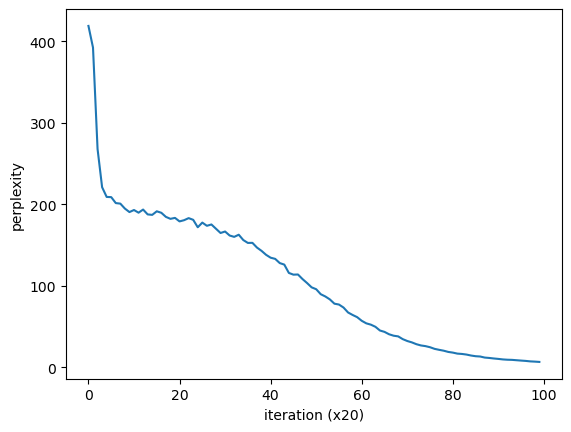

In [1]:
# coding: utf-8
import sys
sys.path.append('..')
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from dataset import ptb
from simple_rnnlm import SimpleRnnlm


# 하이퍼파라미터 설정
batch_size = 10
wordvec_size = 100
hidden_size = 100  # RNN의 은닉 상태 벡터의 원소 수
time_size = 5  # RNN을 펼치는 크기
lr = 0.1
max_epoch = 100

# 학습 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_size = 1000  # 테스트 데이터셋을 작게 설정
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)
xs = corpus[:-1]  # 입력
ts = corpus[1:]  # 출력（정답 레이블）

# 모델 생성
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

trainer.fit(xs, ts, max_epoch, batch_size, time_size)
trainer.plot()
